# Analyse af afledte allel counts i baboon data

Notebokken viser, hvor man:
- Loader genomdata med sgkit 
- Filtrerer et subset af samples
- Beregner derived allele counts (singletons, doubletons, osv.)
- Visualiserer og analyserer resultaterne 

Datasættet er fra Baboon diversity projektet (kromosom 20).

In [4]:
import pandas as pd
import sgkit as sg
import numpy as np
import matplotlib.pyplot as plt


## Load datasæt

In [5]:
# loader zarr-datasættet for chr20
ds = sg.load_dataset("/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR/chr20.phased.rehead.vcz")

ds

<xarray.Dataset> Size: 3GB
Dimensions:               (variants: 2665269, samples: 227, ploidy: 2,
                           contigs: 1, filters: 1, region_index_values: 2666,
                           region_index_fields: 6, alt_alleles: 1, alleles: 2)
Dimensions without coordinates: variants, samples, ploidy, contigs, filters,
                                region_index_values, region_index_fields,
                                alt_alleles, alleles
Data variables: (12/19)
    call_genotype         (variants, samples, ploidy) int8 1GB dask.array<chunksize=(1000, 227, 2), meta=np.ndarray>
    call_genotype_mask    (variants, samples, ploidy) bool 1GB dask.array<chunksize=(1000, 227, 2), meta=np.ndarray>
    call_genotype_phased  (variants, samples) bool 605MB dask.array<chunksize=(1000, 227), meta=np.ndarray>
    contig_id             (contigs) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    filter_description    (filters) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    filter_id             (filters) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    ...                    ...
    variant_filter        (variants, filters) bool 3MB dask.array<chunksize=(1000, 1), meta=np.ndarray>
    variant_id            (variants) object 21MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_id_mask       (variants) bool 3MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_length        (variants) int8 3MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_position      (variants) int32 11MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_quality       (variants) float32 11MB dask.array<chunksize=(1000,), meta=np.ndarray>
Attributes:
    source:                bio2zarr-0.1.7
    vcf_meta_information:  [['fileformat', 'VCFv4.2'], ['fileDate', '06/07/20...
    vcf_zarr_version:      0.4

## Beregn allele counts 

In [6]:
variant_allele_counts = sg.count_variant_alleles(ds)

# variant_allele_count has shape (variants, alleles), dtype uint64
ac = variant_allele_counts["variant_allele_count"].values   # triggers compute
nr_samples = ac.sum(axis=1)              # nr haploid samples (chromosomes)

derived_variant_count_df = pd.DataFrame({
    "position": ds["variant_position"].values,
    "derived_count": ac[:, 1],
    "nr_samples": nr_samples,
})
derived_variant_count_df.head()

,position,derived_count,nr_samples
0,19,13,454
1,73,23,454
2,126,1,454
3,148,1,454
4,149,23,454


Se hvilke samples der findes:

In [7]:
ds['sample_id'].values

array(['Sci_16066', 'Sci_16098', 'Sci_30877', 'Sci_30977', 'Sci_34449',
       'Sci_34474', 'Sci_38168', 'Sci_97074', 'Sci_97124', 'PD_0067',
       'PD_0199', 'PD_0200', 'PD_0201', 'PD_0202', 'PD_0203', 'PD_0204',
       'PD_0205', 'PD_0206', 'PD_0207', 'PD_0208', 'PD_0209', 'PD_0210',
       'PD_0211', 'PD_0212', 'PD_0213', 'PD_0214', 'PD_0215', 'PD_0216',
       'PD_0217', 'PD_0218', 'PD_0219', 'PD_0220', 'PD_0221', 'PD_0222',
       'PD_0223', 'PD_0224', 'PD_0225', 'PD_0226', 'PD_0227', 'PD_0228',
       'PD_0229', 'PD_0230', 'PD_0231', 'PD_0232', 'PD_0233', 'PD_0234',
       'PD_0235', 'PD_0236', 'PD_0237', 'PD_0238', 'PD_0239', 'PD_0240',
       'PD_0241', 'PD_0242', 'PD_0243', 'PD_0244', 'PD_0265', 'PD_0266',
       'PD_0267', 'PD_0268', 'PD_0269', 'PD_0270', 'PD_0271', 'PD_0272',
       'PD_0390', 'PD_0391', 'PD_0392', 'PD_0393', 'PD_0394', 'PD_0395',
       'PD_0396', 'PD_0397', 'PD_0398', 'PD_0399', 'PD_0400', 'PD_0401',
       'PD_0492', 'PD_0493', 'PD_0494', 'PD_0495', 'PD_

## Udvælges af et subset af samples

Specifikke individer udvælges. 

In [8]:
keep = ['PD_0199', 'PD_0200', 'PD_0201', 'PD_0202', 'PD_0203']
mask = ds["sample_id"].isin(keep).values
ds_sub = ds.isel(samples=mask)

ds_sub

<xarray.Dataset> Size: 189MB
Dimensions:               (variants: 2665269, samples: 5, ploidy: 2,
                           contigs: 1, filters: 1, region_index_values: 2666,
                           region_index_fields: 6, alt_alleles: 1, alleles: 2)
Dimensions without coordinates: variants, samples, ploidy, contigs, filters,
                                region_index_values, region_index_fields,
                                alt_alleles, alleles
Data variables: (12/19)
    call_genotype         (variants, samples, ploidy) int8 27MB dask.array<chunksize=(1000, 5, 2), meta=np.ndarray>
    call_genotype_mask    (variants, samples, ploidy) bool 27MB dask.array<chunksize=(1000, 5, 2), meta=np.ndarray>
    call_genotype_phased  (variants, samples) bool 13MB dask.array<chunksize=(1000, 5), meta=np.ndarray>
    contig_id             (contigs) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    filter_description    (filters) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    filter_id             (filters) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    ...                    ...
    variant_filter        (variants, filters) bool 3MB dask.array<chunksize=(1000, 1), meta=np.ndarray>
    variant_id            (variants) object 21MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_id_mask       (variants) bool 3MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_length        (variants) int8 3MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_position      (variants) int32 11MB dask.array<chunksize=(1000,), meta=np.ndarray>
    variant_quality       (variants) float32 11MB dask.array<chunksize=(1000,), meta=np.ndarray>
Attributes:
    source:                bio2zarr-0.1.7
    vcf_meta_information:  [['fileformat', 'VCFv4.2'], ['fileDate', '06/07/20...
    vcf_zarr_version:      0.4

## Beregn variant allele counts

Bregner antal alleler pr. variant.

In [9]:
variant_allele_counts = sg.count_variant_alleles(ds_sub)

ac = variant_allele_counts["variant_allele_count"].values
nr_samples = ac.sum(axis=1)


variant_allele_counts = sg.count_variant_alleles(ds)

Opret dataframe med derived allele counts

In [11]:
derived_variant_count_df = pd.DataFrame({
    "position": ds_sub["variant_position"].values,
    "derived_count": ac[:, 1],
    "nr_samples": nr_samples,
})
derived_variant_count_df.head()

,position,derived_count,nr_samples
0,19,0,10
1,73,0,10
2,126,0,10
3,148,0,10
4,149,0,10


## Fordeling af derived allele counts

In [12]:
derived_variant_count_df["derived_count"].value_counts().sort_index()

derived_count
0     2276289
1      122561
2       69836
3       45343
4       31865
5       26285
6       21450
7       17838
8       15897
9       13876
10      24029
Name: count, dtype: int64

## Histogram af derived allele counts

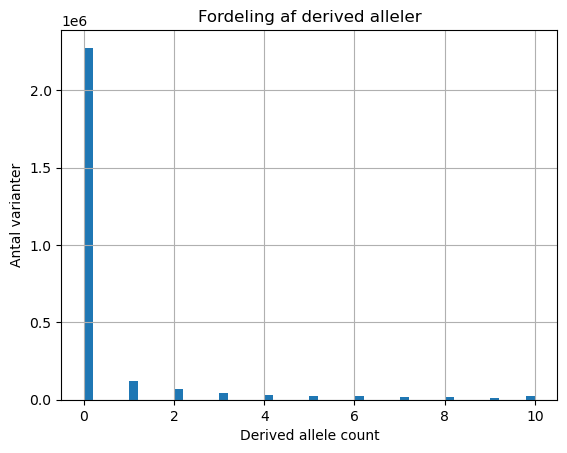

In [13]:
plt.figure()
derived_variant_count_df["derived_count"].hist(bins=50)
plt.xlabel("Derived allele count")
plt.ylabel("Antal varianter")
plt.title("Fordeling af derived alleler")
plt.show()

## Frekvens (allele frequency)

In [14]:
derived_variant_count_df["frequency"] = (
    derived_variant_count_df["derived_count"] /
    derived_variant_count_df["nr_samples"]
)

Filtrer sjældne varianter

In [15]:
rare = derived_variant_count_df[derived_variant_count_df["derived_count"] <= 2]
rare.head()

,position,derived_count,nr_samples,frequency
0,19,0,10,0.0
1,73,0,10,0.0
2,126,0,10,0.0
3,148,0,10,0.0
4,149,0,10,0.0


Plot frekvens

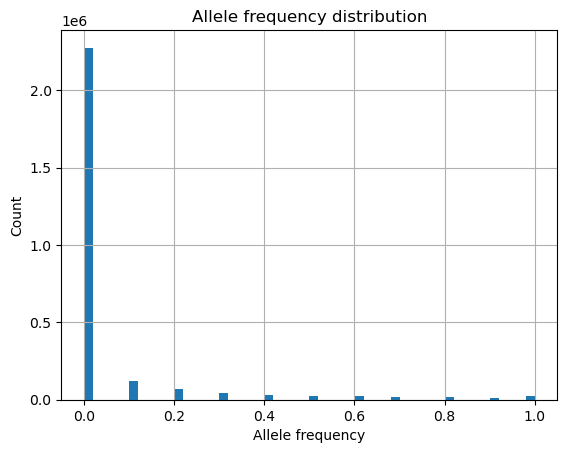

In [16]:
plt.figure()
derived_variant_count_df["frequency"].hist(bins=50)
plt.xlabel("Allele frequency")
plt.ylabel("Count")
plt.title("Allele frequency distribution")
plt.show()